In [3]:
# Multivariate data exploration.
# Intent of this file is to analyze data from the National Survey of College Graduates (NSCG) using data regarding 2017 graudates.
# Focus on mechanical engineers.

# Setup:
import math
import collections

import numpy
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
import datetime
from matplotlib import style
#importing seaborn for nice boxplots
import seaborn as sns
# For Pearson correlation coefficient, importing scipy
from scipy.stats.stats import pearsonr


C:\Users\Brad\AppData\Local\Temp\ipykernel_17140\1733088074.py:19: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


In [4]:
# Import the 'ME_salaries.csv' file from the data directory

me_sal = pd.read_csv('../../data/ME_salaries.csv', names=['Salary', 'Age', 'Gender'], skiprows=1)
print(me_sal.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3616 entries, 0 to 3615
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Salary  3616 non-null   int64 
 1   Age     3616 non-null   int64 
 2   Gender  3616 non-null   object
dtypes: int64(2), object(1)
memory usage: 84.9+ KB
None


In [5]:
# Looking at respondents who didn't list their salary, pd.isnull isn't working to find empty arrays of "" recorded for salary.
# However there are 15 respondents who answered having 0 for their salary:
me_no_sal = me_sal.loc[me_sal['Salary'] == 0]

# Therefore it would make sense to remove these responses at outliers, there could be many reasons why someone would list their salary at 0.
me_sal = me_sal.loc[me_sal['Salary'] != 0]
# Need to reset the index after removing some rows:
me_sal.reset_index(drop=True, inplace=True)

In [6]:
# Taking a look at the genders shown in the dataframe:
print(me_sal.Gender.value_counts())

# It appears that 3228 men and 373 women responded with no other possible gender identities being listed.


Gender
M    3228
F     373
Name: count, dtype: int64


0       32
1       31
2       38
3       36
4       60
        ..
3596    32
3597    28
3598    56
3599    58
3600    40
Name: Age, Length: 3601, dtype: int64
Age
75      5
73      5
71      7
23      8
74     11
72     12
70     13
66     19
67     20
68     20
69     22
64     22
65     23
61     32
62     34
63     34
24     38
60     42
41     54
39     55
50     59
58     61
51     62
44     63
48     64
40     64
49     64
59     66
47     69
46     70
54     70
56     71
25     72
43     72
52     73
57     74
38     75
45     76
42     77
37     82
55     87
35     87
53     87
36     88
26    103
34    125
27    137
33    139
28    143
32    165
31    185
29    194
30    201
Name: count, dtype: int64
53


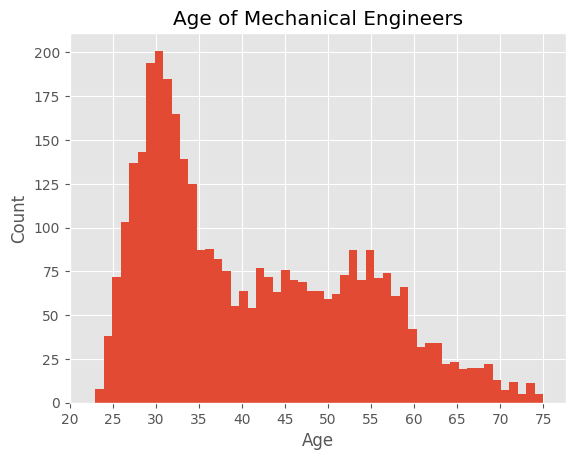

In [7]:
# With the data imported, plots could provide more insight into each category.
# print(me_sal.Age.value_counts())

# ages = me_sal.sort_values('Age')
age_count = me_sal['Age']

# age_count = age_count.sort_values(ascending=True)
print(age_count)
print(age_count.value_counts().sort_values(ascending=True))
# How many bins should be in the histogram should be equal to the number of unique ages recorded
print(len(me_sal.Age.unique()))
# Plotting the age of mechanical engineers that responded in a histogram.
style.use('ggplot')
plt.hist(me_sal['Age'],
         bins=len(me_sal.Age.unique()))
plt.title('Age of Mechanical Engineers')
plt.xlabel('Age')
plt.xticks(np.linspace(20, 75, 12))
plt.ylabel('Count')
plt.show()

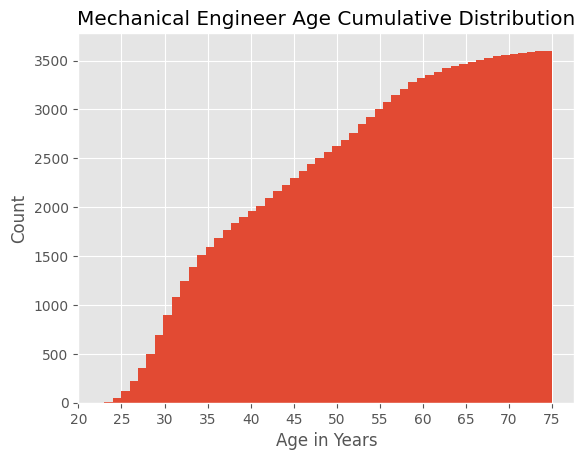

In [8]:
# A cumulative distribution plot would also be nice:
plt.hist(me_sal['Age'],
         bins=len(me_sal.Age.unique()),
         cumulative=True)
plt.title('Mechanical Engineer Age Cumulative Distribution' )
plt.xlabel('Age in Years')
plt.xticks(np.linspace(20, 75, 12))
plt.ylabel('Count')
plt.show()

Gender
M    3228
F     373
Name: count, dtype: int64


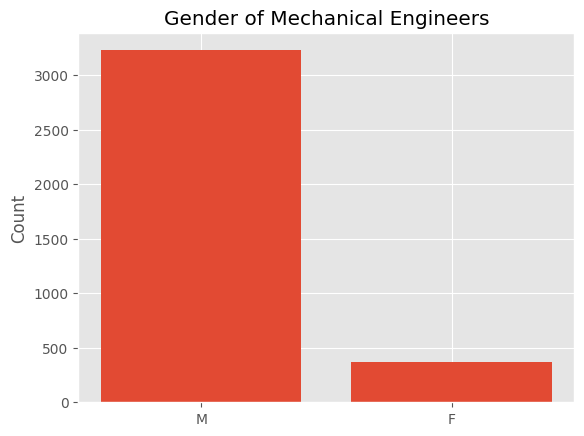

In [9]:
# Exploring Gender of mechanical engineers, a barchart would help compare how many of each there are:

me_gender = me_sal.Gender.unique()
me_genderCt = me_sal.Gender.value_counts()
print(me_genderCt)

plt.bar(me_gender,me_genderCt)
plt.title('Gender of Mechanical Engineers')
plt.ylabel('Count')
plt.yticks(numpy.arange(0, 3500, 500))
plt.show()

      Salary  Age Gender
3     130000   36      F
17     80228   37      F
19    112000   33      F
25     62000   37      F
38     24000   47      F
...      ...  ...    ...
3557   83500   32      F
3558   75000   29      F
3560     140   29      F
3564   31200   54      F
3596  107200   32      F

[373 rows x 3 columns]


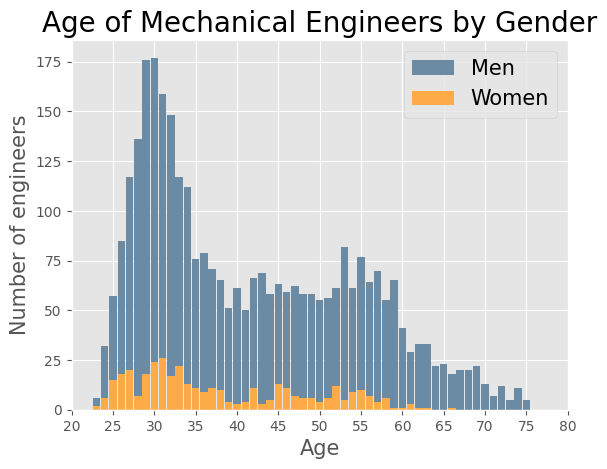

In [10]:
#Perhaps an age histogram that compares gender would also be interesting:

# Separating both men and women responses:
me_men = me_sal.loc[me_sal['Gender'] == 'M']
me_women = me_sal.loc[me_sal['Gender'] == 'F']

# A unique challenge here, there are some ages that have no women in that bin, therefore stacking the bins with two plots has the bins offset from one another.

print(me_women)
# Simple solution, just make the range of the bins available, and make the steps be by 1 for intergers.
plt.hist(me_men['Age'],
         bins=range(0,100,1),
         color='xkcd:grey blue',
         rwidth=0.9,
         stacked=True,
         align='left')
plt.hist(me_women['Age'],
         bins=range(0,100,1),
         color='xkcd:light orange',
         rwidth=0.9,
         stacked=True,
         align='left')
plt.title('Age of Mechanical Engineers by Gender', fontsize=20)
plt.legend(labels=['Men', 'Women'], fontsize= 15)
plt.xlabel('Age', fontsize=15)
plt.ylabel('Number of engineers', fontsize=15)
plt.xlim(20,80)
plt.xticks(list(range(20,85,5)))
plt.show()

# hard to tell if there is a correlation between age and gender, another plot may be required, but the information is interesting regardless.

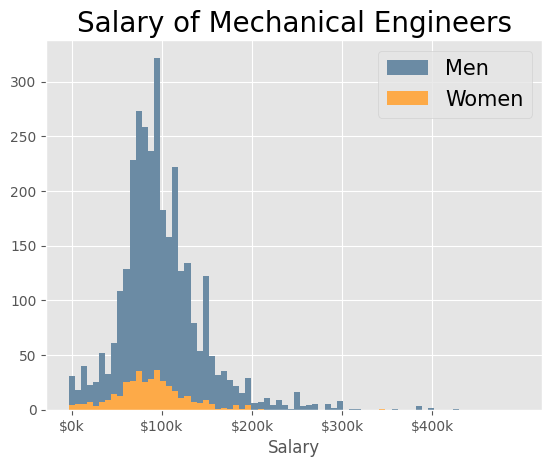

In [11]:
#Comparing salary versus gender instead:
salary_ticks= list(range(0,500,100))
plt.hist(me_men['Salary'],
         bins=np.linspace(0, 500000, 75),
         color='xkcd:grey blue',
         stacked=True,
         align='left')
plt.hist(me_women['Salary'],
         bins=np.linspace(0,500000,75),
         color='xkcd:light orange',
         stacked=True,
         align='left')
plt.title('Salary of Mechanical Engineers', fontsize=20)
plt.xlabel('Salary')
plt.xticks(list(range(0,500000,100000)), [f"${x}k" for x in salary_ticks])
plt.legend(labels=['Men', 'Women'], fontsize=15)
plt.show()

C:\Users\Brad\AppData\Local\Temp\ipykernel_17140\4176358549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=me_sal, x='Salary', y= 'Gender',


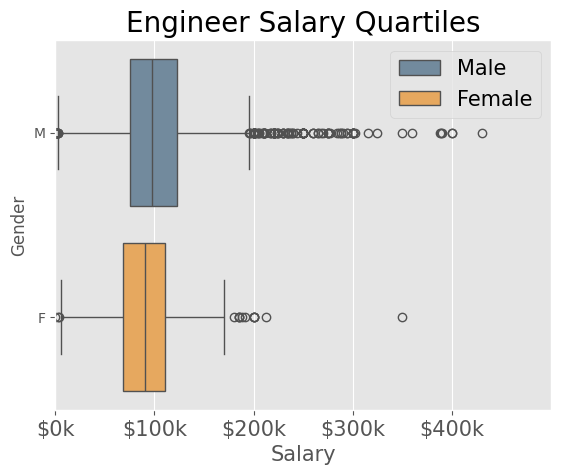

In [12]:
#Again hard to tell the difference at a glance with the population differences.

# A side by side boxplot will give information regarding quartiles and the median, possibly giving insights.
# seaborn makes a asethicically nice box plot, which can convey infomation easliy.
# plt.style.use('bmh')
sns.boxplot(data=me_sal, x='Salary', y= 'Gender',
            palette=[sns.xkcd_rgb['grey blue'], sns.xkcd_rgb['light orange']])
plt.title('Engineer Salary Quartiles', fontsize=20)
plt.xlabel('Salary', fontsize=15)
plt.xticks(list(range(0,500000,100000)), [f"${x}k" for x in salary_ticks], fontsize=15)
plt.xlim(0,500000)
plt.legend(['Male', 'Female'], fontsize=15)

plt.show()
# while not perfect, its a start. Would like to make the fontsize larger for the y axis.


C:\Users\Brad\AppData\Local\Temp\ipykernel_17140\1215831997.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=me_sal, x='Age', y='Gender',


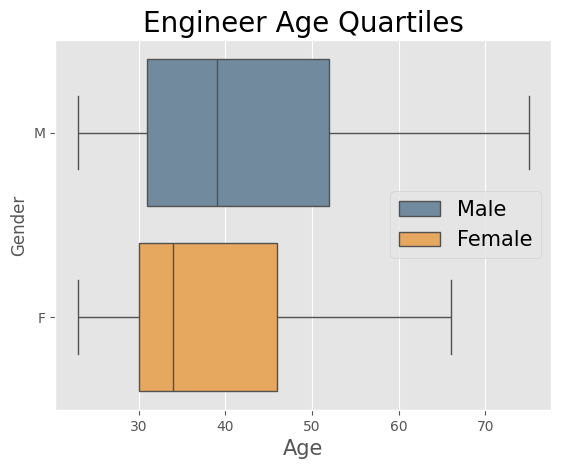

In [13]:
# Boxplot for age of mechanical engineers with gender in mind:
sns.boxplot(data=me_sal, x='Age', y='Gender',
            palette=[sns.xkcd_rgb['grey blue'], sns.xkcd_rgb['light orange']])
plt.title('Engineer Age Quartiles', fontsize=20)
plt.xlabel('Age', fontsize=15)
plt.legend(['Male','Female'],fontsize=15)
plt.show()


In [14]:
# looking at both boxplots, they would imply that female engineers as a median have slighly lower salaries than their male counterparts.
# It also appears that a larger porportion of women engineers are younger.


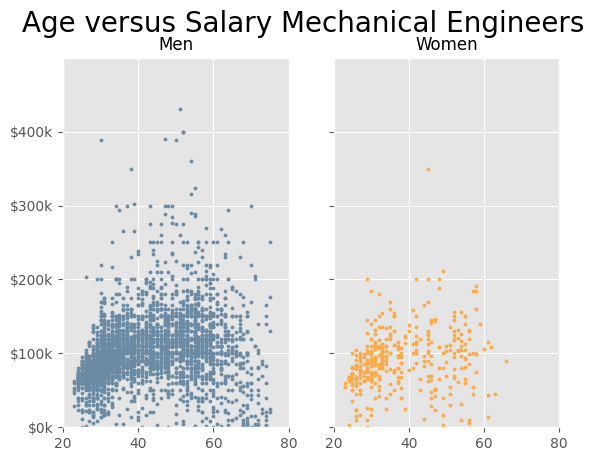

In [15]:
#a scatterplot showing the age(x-axis) vs Salary may show trends between the two, where we would expect older engineers to be paid more.
# Having 1 plot containing both the data for men and women superimposed on one another is difficult to read, so two subplots seems to be a better option.

fig, ax = plt.subplots(1, 2, sharey=True)
ax[0].scatter(me_men['Age'], me_men['Salary'],
            c='xkcd:grey blue',
            s=5,
            alpha= 1)
ax[1].scatter(me_women['Age'], me_women['Salary'],
            c='xkcd:light orange',
            s=5,
            alpha= 1)
ax[0].set_title('Men', fontsize=12)
ax[0].set_ylim(0,500000)
ax[0].set_yticks(list(range(0,500000,100000)), [f"${x}k" for x in salary_ticks])
ax[0].set_xlim(20,80)
ax[1].set_xlim(20,80)
ax[1].set_title('Women', fontsize=12)
fig.suptitle('Age versus Salary Mechanical Engineers', fontsize=20)
plt.show()

In [16]:
#This plot will have different readability depening upon the size of the window it is opened in.
# A large number of datapoints makes it difficult to read if the points are too large due to overlap.
# In a small preview window, the marker points are small
# However, in a large window the marker points may need to be larger (s goes up) as they don't scale with the window itself.


In [21]:
# A pearson coefficent here could show a correlation between age and salary.
cor_eng, p = pearsonr(me_sal['Age'], me_sal['Salary'])
cor_eng
print(f'The Pearsons correlation between age and salary for mechanical engineers is %.3f' %cor_eng)

The Pearsons correlation between age and salary for mechanical engineers is 0.208


In [23]:
# Checking for each gender now:
cor_men, p_men = pearsonr(me_men['Age'], me_men['Salary'])
print(f'The Pearsons correlation for age vs salary for men is %.3f' %cor_men )
cor_women, p_women = pearsonr(me_women['Age'], me_women['Salary'])
print(f'Likewise the Pearsons correlation for women is %.3f' %cor_women)

The Pearsons correlation for age vs salary for men is 0.203
Likewise the Pearsons correlation for women is 0.212


In [ ]:
# It would appear that the pearson correlation between age and salary has a slight positive value, and doesn't have a signifigant difference between men and women.
# Looking at the scatterplot above, it appears that young engineers have entry level salaries that are grouped together, but as time goes on the salaries gain variance.

In [46]:
# a cumulative distribuiton comparing salary may discern what salary the majority of engineers should expect in their careers.
x_men = np.sort(me_men['Salary'])
x_fem = np.sort(me_women['Salary'])

y_men = np.arange(len(me_men))/ float(len(me_men))
y_fem = np.arange(len(me_women))/ float(len(me_women))


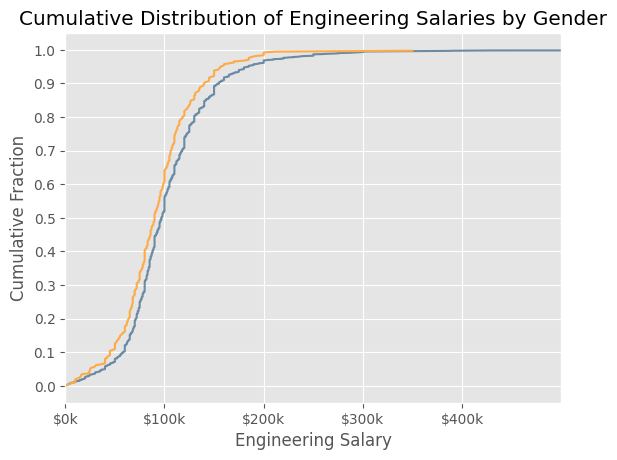

In [58]:
plt.plot(x_men,y_men, c='xkcd:grey blue')
plt.plot(x_fem,y_fem, c='xkcd:light orange')
# After a preliminary look at  the graph, the plot is affected by a couple of outliers with a few people making around 1 million dollars. In this case they will be removed from this plot 
plt.title('Cumulative Distribution of Engineering Salaries by Gender' )
plt.xlabel('Engineering Salary')
plt.ylabel('Cumulative Fraction')
plt.xlim(0,500000)
plt.xticks(list(range(0,500000,100000)), [f"${x}k" for x in salary_ticks])
plt.yticks(np.arange(0,1.1,0.1))
plt.legend(['Men', 'Women'])
plt.show()

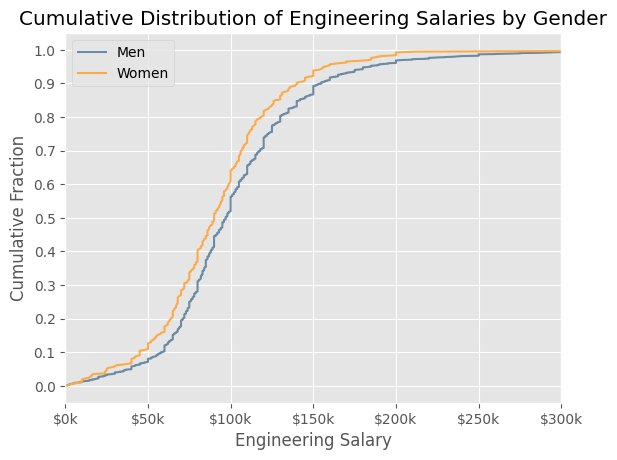

In [62]:
# Looking at this plot, it appears that about 99% of engineers make less than 250k, so it may be beneficial to zoom in to notice differences more easily.
sal_ticks2 = list(range(0,350,50))
plt.plot(x_men,y_men, c='xkcd:grey blue')
plt.plot(x_fem,y_fem, c='xkcd:light orange')
# After a preliminary look at  the graph, the plot is affected by a couple of outliers with a few people making around 1 million dollars. In this case they will be removed from this plot 
plt.title('Cumulative Distribution of Engineering Salaries by Gender' )
plt.xlabel('Engineering Salary')
plt.ylabel('Cumulative Fraction')
plt.xlim(0,300000)
plt.xticks(list(range(0,350000,50000)), [f"${x}k" for x in sal_ticks2])
plt.yticks(np.arange(0,1.1,0.1))
plt.legend(['Men', 'Women'])
plt.show()

In [ ]:
# This plot is rather unfortunate, which suggests that women are statistically less likely to make the same wage as their male counterparts
# The quantiles were shown in the boxplot earlier, but calculating them could be useful


In [67]:
me_women.Salary.describe()

count       373.000000
mean      91619.975871
std       40055.933664
min         140.000000
25%       68000.000000
50%       90000.000000
75%      110513.000000
max      350000.000000
Name: Salary, dtype: float64

In [69]:
me_men.Salary.describe()

count    3.228000e+03
mean     1.041879e+05
std      5.838181e+04
min      1.050000e+02
25%      7.500000e+04
50%      9.700000e+04
75%      1.230000e+05
max      1.027653e+06
Name: Salary, dtype: float64

In [76]:
quantile_f = me_women.Salary.quantile([0, 0.25, 0.5, 0.75, 1.0])

In [77]:
quantile_m = me_men.Salary.quantile([0, 0.25, 0.5, 0.75, 1.0])

In [86]:
print(f'The median salary for women is $%.0f' %quantile_f.iloc[2])

The median salary for women is $90000


In [85]:
print(f'The median salary for men is $%.0f' %quantile_m.iloc[2])

The median salary for men is $97000


In [88]:
print(f'The difference in the medians is: $%.0f' %(quantile_m.iloc[2]-quantile_f.iloc[2]))

The difference in the medians is: $7000


In [90]:
print(f'Maximum salary for women is $%.0f' %quantile_f.iloc[4])

Maximum salary for women is $350000


In [91]:
print(f'Maximum salary for men is $%.0f' %quantile_m.iloc[4])

Maximum salary for men is $1027653


In [92]:
print(f'The difference in the maximum is $%.0f' %(quantile_m.iloc[-1]-quantile_f.iloc[-1]))

The difference in the maximum is $677653


In [ ]:
There are a large number of potential factors in play for overall pay of employees, but the largest one might be the company and occupation of each engineer. If a company and type  of engineering could be found, it would be helpful. Also it seems that the pay for many engineers plateaus at around 100k. It could be helpful to know which engineers have management positions. The school each engineer graduated at may play a small role in salary, as new hires out of prestigous schools may be offered more to start. Also where the engineer lives would play a role in pay considering cost of living, and potential benefits. 